In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.animation as animation

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation

def update_frame(frame):
    words = df[df['Order'] <= frame]
    if not words.empty:
        latest_word = words.sort_values(by='Order', ascending=False).iloc[0]
        top = latest_word['Top']
        bottom = latest_word['Bottom']
        left = latest_word['Left']
        right = latest_word['Right']

        if pd.notnull(top) and pd.notnull(bottom) and pd.notnull(left) and pd.notnull(right):
            top = [float(top.strip('[]').split(',')[0]), float(top.strip('[]').split(',')[1])]
            bottom = [float(bottom.strip('[]').split(',')[0]), float(bottom.strip('[]').split(',')[1])]
            left = [float(left.strip('[]').split(',')[0]), float(left.strip('[]').split(',')[1])]
            right = [float(right.strip('[]').split(',')[0]), float(right.strip('[]').split(',')[1])]

            top_left = [left[0], top[1]]
            bottom_right = [right[0], bottom[1]]
            bottom_left = [left[0], bottom[1]]
            top_right = [right[0], top[1]]

            height = bottom_left[1] - top_left[1]
            width = top_right[0] - top_left[0]

            highlight_patch.set_xy(top_left)
            highlight_patch.set_width(width)
            highlight_patch.set_height(height)
        else:
            # Hide the patch if word data is missing
            highlight_patch.set_width(0)
            highlight_patch.set_height(0)

    return highlight_patch,



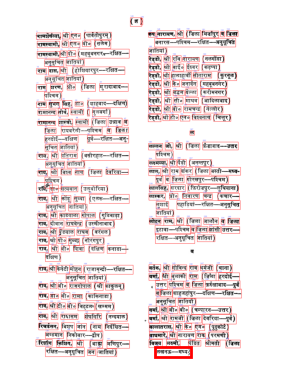

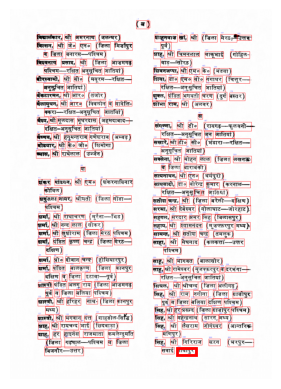

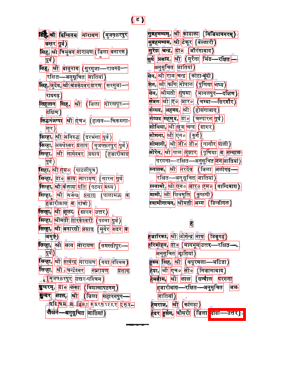

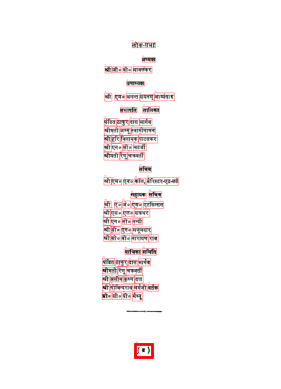

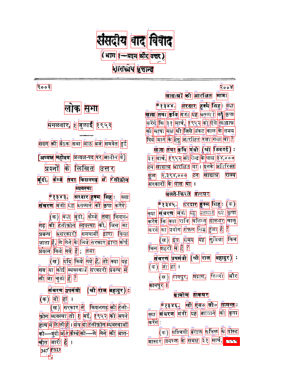

In [ ]:
csv_file = "Euclidean.csv"
dff = pd.read_csv(csv_file)
df = dff.sort_values(by=["Order"], ascending=True)
fig, ax = plt.subplots()
ax.set_facecolor('white')

image_file = "Image.png"
image = plt.imread(image_file)
ax.imshow(image)
ax.axis('off')


highlight_patch = plt.Rectangle((0, 0), 1, 1, linewidth=2, edgecolor='r', facecolor='none',fill = True)
ax.add_patch(highlight_patch)
num_frames = len(df)
anim = animation.FuncAnimation(fig, update_frame, frames=num_frames, interval=1000, repeat=True)

anim.save('Video.mp4', writer = 'ffmpeg', fps = 25)

plt.show()
